<a href="https://colab.research.google.com/github/CarlosOrte/Descriptive-and-Predictive-Analytics-Code/blob/main/Proyecto_An%C3%A1lisis_Exploratorio_de_Datos_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 **Proyecto: Análisis Exploratorio de Datos (EDA)**
## Mestría en Inteligencia Artificial y Analitica de datos
### Programación para Analítica Descriptiva y Predictiva


**Dataset:** Calidad del aire – datos históricos diarios  
**Alumno:** Carlos Alberto Ortega Chavez  
**Fecha:** 3-24-2026

---



# 🌎 Fuente y contexto del dataset

### ¿De dónde proviene?
El dataset proviene del portal oficial de **Datos Abiertos de la Junta de Castilla y León (España)**, dentro de la iniciativa de datos abiertos del gobierno regional.

Fue publicado por la **Dirección General de Infraestructuras y Sostenibilidad Ambiental – Consejería de Medio Ambiente, Vivienda y Ordenación del Territorio**.  

### ¿Es real o simulado?
Es un conjunto de datos **real**, obtenido a partir de mediciones registradas por estaciones oficiales de control de calidad del aire.

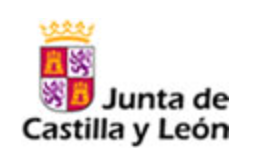

In [35]:
# ===============================
# CARGA DEL DATASET
# ===============================

import pandas as pd

# Cargar archivo CSV
df = pd.read_csv('/content/drive/MyDrive/calidad-del-aire-datos-historicos-diarios.csv', sep=";")

# Convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Mostrar primeras filas
df.head()


,Fecha,CO (mg/m3),NO (ug/m3),NO2 (ug/m3),O3 (ug/m3),PM10 (ug/m3),PM25 (ug/m3),SO2 (ug/m3),Provincia,Estación,Latitud,Longitud,Posición
0,2020-12-31,NaN,7.0,22.0,45.0,3.0,NaN,9.0,León,C.T.L.R. - Cuadros,42.715556,-5.638889,"42.7155555556,-5.63888888889"
1,2020-12-31,NaN,NaN,NaN,NaN,6.0,NaN,4.0,León,Otero,42.564444,-6.781944,"42.5644444444,-6.78194444444"
2,2020-12-31,NaN,6.0,16.0,64.0,4.0,NaN,2.0,Soria,Soria,41.767222,-2.480556,"41.7672222222,-2.48055555556"
3,2020-12-31,NaN,1.0,1.0,53.0,1.0,1.0,3.0,Palencia,C.T.G. - Compuerto,42.849167,-4.835833,"42.8491666667,-4.83583333333"
4,2020-12-31,NaN,2.0,21.0,41.0,NaN,NaN,NaN,Valladolid,Michelin1,41.666389,-4.715000,"41.6663888889,-4.715"


## 🌫 Principales contaminantes del dataset

- 🚗 **CO (mg/m³)**: Gas de combustión vehicular. Reduce la capacidad de la sangre para transportar oxígeno.

- 🔥 **NO (µg/m³)**: Emitido por motores e industria. Participa en la formación de otros contaminantes.

- 🚦 **NO2 (µg/m³)**: Asociado al tráfico. Irrita vías respiratorias y aumenta riesgo de asma.

- ☀️ **O3 (µg/m³)**: Se forma por reacciones químicas con luz solar. Afecta el sistema respiratorio.

- 🌪 **PM10 (µg/m³)**: Partículas suspendidas en el aire. Pueden entrar al sistema respiratorio.

- 🫁 **PM25 (µg/m³)**: Partículas finas más peligrosas. Penetran profundamente en los pulmones.

- 🏭 **SO2 (µg/m³)**: Gas de combustibles fósiles e industria. Puede causar irritación respiratoria.



#📌 1. DESCRIPCIÓN DEL DATASET

In [36]:
print("Forma del dataset:", df.shape)
df.info()

# Tipos de variables
print("\nTipos de variables:")
print(df.dtypes)

# Estadísticas
df.describe()

Forma del dataset: (446014, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446014 entries, 0 to 446013
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Fecha         446014 non-null  datetime64[ns]
 1   CO (mg/m3)    101158 non-null  float64       
 2   NO (ug/m3)    415030 non-null  float64       
 3   NO2 (ug/m3)   413497 non-null  float64       
 4   O3 (ug/m3)    275414 non-null  float64       
 5   PM10 (ug/m3)  344579 non-null  float64       
 6   PM25 (ug/m3)  53784 non-null   float64       
 7   SO2 (ug/m3)   356277 non-null  float64       
 8   Provincia     446014 non-null  object        
 9   Estación      446014 non-null  object        
 10  Latitud       445788 non-null  float64       
 11  Longitud      445788 non-null  float64       
 12  Posición      445788 non-null  object        
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 44.2+ MB

Tipos de variables:

,Fecha,CO (mg/m3),NO (ug/m3),NO2 (ug/m3),O3 (ug/m3),PM10 (ug/m3),PM25 (ug/m3),SO2 (ug/m3),Latitud,Longitud
count,446014,101158.000000,415030.000000,413497.000000,275414.000000,344579.000000,53784.000000,356277.000000,445788.000000,445788.000000
mean,2009-09-11 22:19:36.598044160,0.854624,13.225808,21.409154,52.619754,22.694662,13.677172,9.092801,42.151547,-5.178965
min,1997-01-01 00:00:00,0.000000,-441.000000,0.000000,0.000000,0.000000,0.000000,-791.000000,38.938333,-6.781944
25%,2004-07-26 00:00:00,0.300000,2.000000,8.000000,37.000000,11.000000,5.000000,2.000000,41.645556,-6.483889
50%,2009-09-11 00:00:00,0.700000,5.000000,16.000000,54.000000,18.000000,9.000000,5.000000,42.542778,-4.909167
75%,2015-02-10 00:00:00,1.100000,15.000000,29.000000,68.000000,29.000000,15.000000,11.000000,42.688056,-4.538333
max,2020-12-31 00:00:00,25.100000,634.000000,249.000000,999.000000,557.000000,223.000000,364.000000,43.603333,-2.466667
std,NaN,0.785226,21.970729,19.108434,23.221958,17.919319,15.895495,13.790750,0.665501,1.121920


El dataset contiene mediciones diarias de contaminantes atmosféricos.
Incluye variables numéricas (contaminantes), categóricas (provincia, estación) y temporales (fecha).

#🔍 2. CALIDAD DE DATOS

In [37]:
# Valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

# Duplicados
print("\nDuplicados:", df.duplicated().sum())

# Nombres de columnas
print("\nColumnas:")
print(df.columns)


Valores faltantes:
Fecha                0
CO (mg/m3)      344856
NO (ug/m3)       30984
NO2 (ug/m3)      32517
O3 (ug/m3)      170600
PM10 (ug/m3)    101435
PM25 (ug/m3)    392230
SO2 (ug/m3)      89737
Provincia            0
Estación             0
Latitud            226
Longitud           226
Posición           226
dtype: int64

Duplicados: 0

Columnas:
Index(['Fecha', 'CO (mg/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'O3 (ug/m3)',
       'PM10 (ug/m3)', 'PM25 (ug/m3)', 'SO2 (ug/m3)', 'Provincia', 'Estación',
       'Latitud', 'Longitud', 'Posición'],
      dtype='object')


Se detectan valores faltantes en varios contaminantes y posibles inconsistencias.

#🧹 3. PREPROCESAMIENTO
##🔹 3.1 Valores faltantes

In [38]:
# Rellenar con la media
df.fillna(df.mean(numeric_only=True), inplace=True)

##🔹 3.2 Outliers (IQR)

In [54]:
def eliminar_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

# Aplicar a una variable ejemplo
df = eliminar_outliers(df, "NO2 (ug/m3)")

##🔹 3.3 Transformaciones

In [40]:
# Crear columnas de tiempo
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

Se limpiaron datos faltantes, se eliminaron valores extremos y se crearon variables temporales.

##📊 4. ANÁLISIS UNIVARIADO

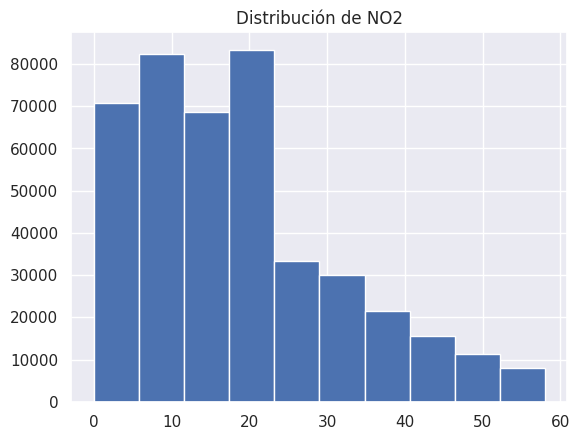

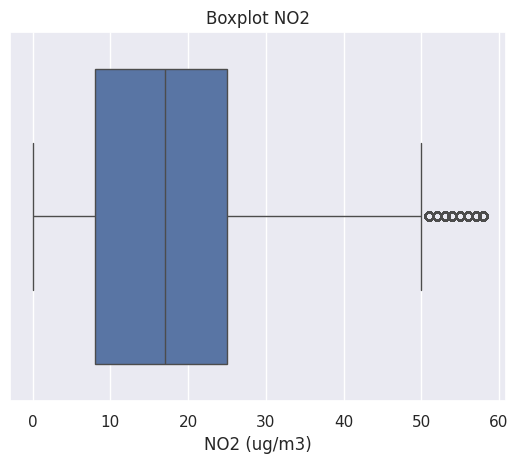

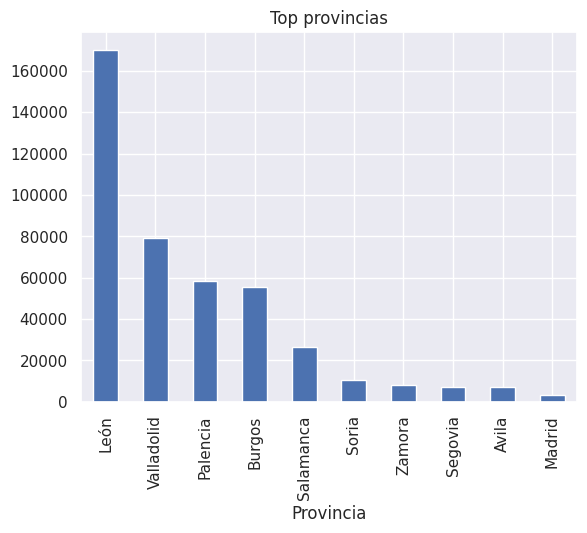

In [41]:
# Histograma
plt.figure()
df["NO2 (ug/m3)"].hist()
plt.title("Distribución de NO2")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x=df["NO2 (ug/m3)"])
plt.title("Boxplot NO2")
plt.show()

# Variable categórica
plt.figure()
df["Provincia"].value_counts().head(10).plot(kind="bar")
plt.title("Top provincias")
plt.show()

Se analizó la distribución de contaminantes y frecuencia por provincia.

##🔗 5. ANÁLISIS BIVARIADO

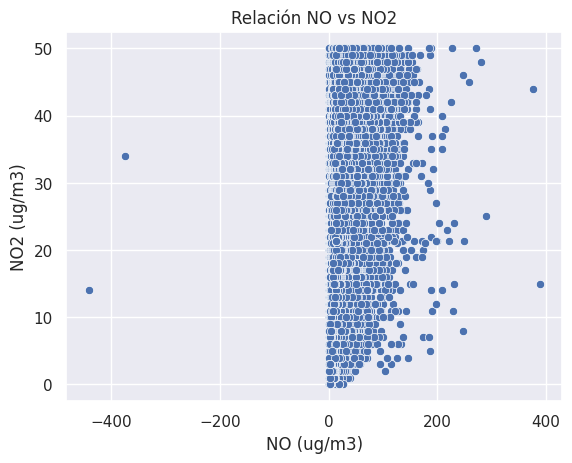

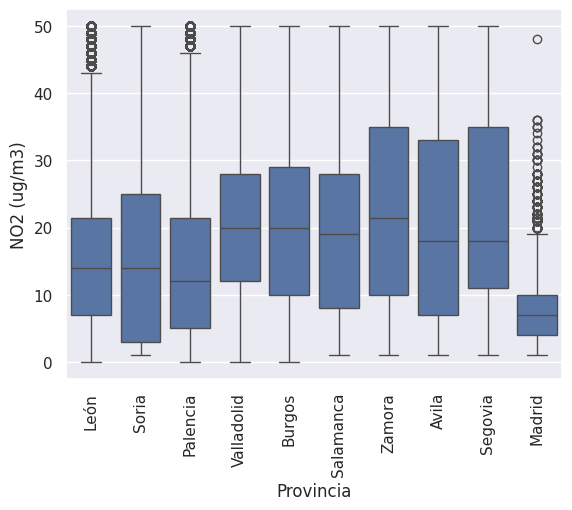

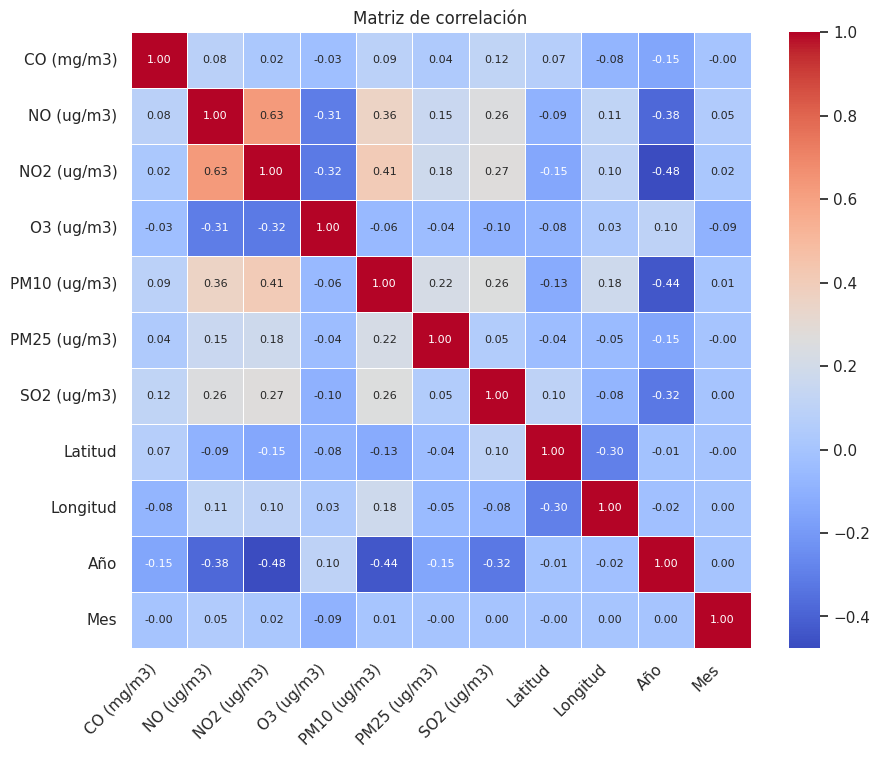

In [55]:
# Scatter
plt.figure()
sns.scatterplot(x="NO (ug/m3)", y="NO2 (ug/m3)", data=df)
plt.title("Relación NO vs NO2")
plt.show()

# Boxplot por categoría
plt.figure()
sns.boxplot(x="Provincia", y="NO2 (ug/m3)", data=df)
plt.xticks(rotation=90)
plt.show()

# Correlación
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size":8},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.title("Matriz de correlación")
plt.show()

Se observan relaciones entre contaminantes y diferencias entre provincias.

##🧠 6. ANÁLISIS MULTIVARIADO

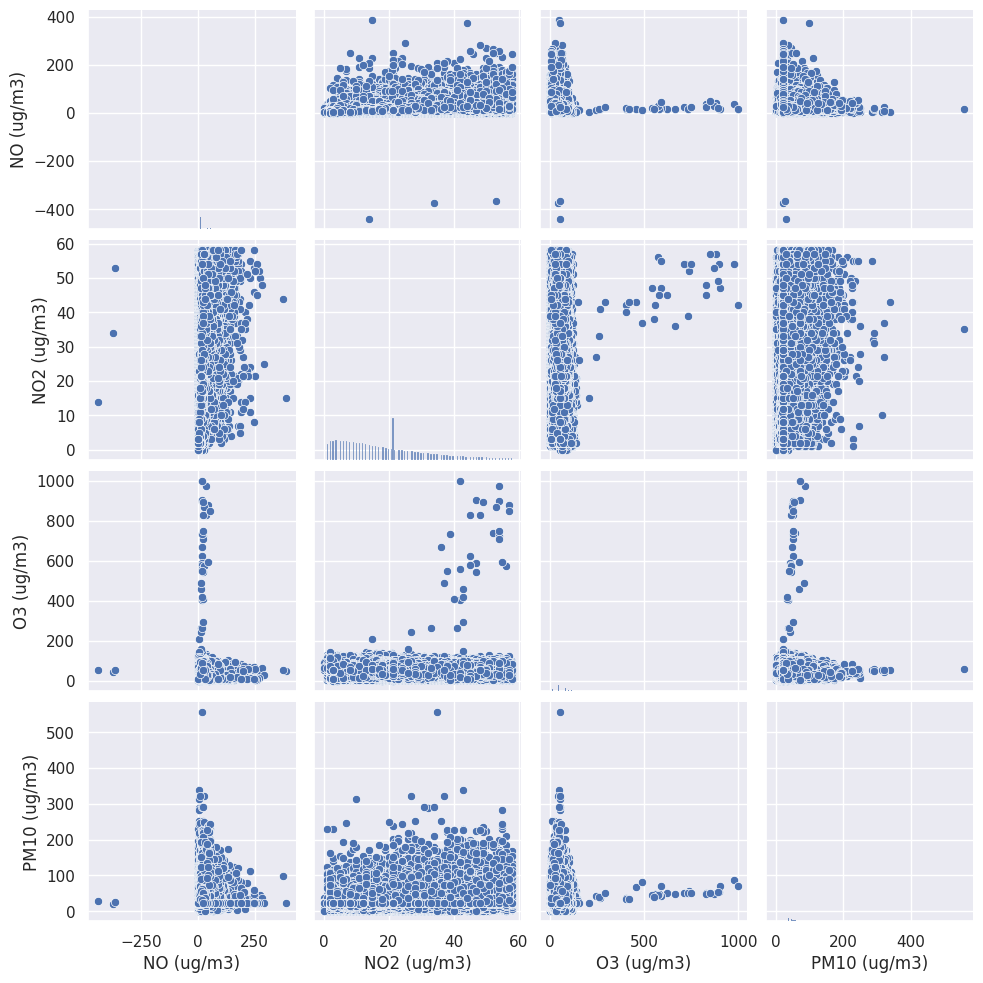

In [43]:
# Pairplot
sns.pairplot(df[["NO (ug/m3)", "NO2 (ug/m3)", "O3 (ug/m3)", "PM10 (ug/m3)"]])
plt.show()

Se analizan múltiples variables simultáneamente para detectar patrones.

##❓ 7. VISUALIZACIONES PARA PREGUNTAS
📌 Pregunta 1: ¿Cómo varía la contaminación en el tiempo?

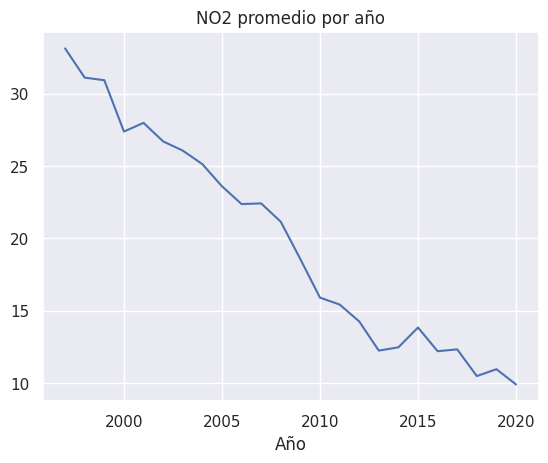

In [44]:
plt.figure()
df.groupby("Año")["NO2 (ug/m3)"].mean().plot()
plt.title("NO2 promedio por año")
plt.show()

Permite ver tendencias a largo plazo de la contaminación.

📌 Pregunta 2: ¿Qué contaminante es más alto?

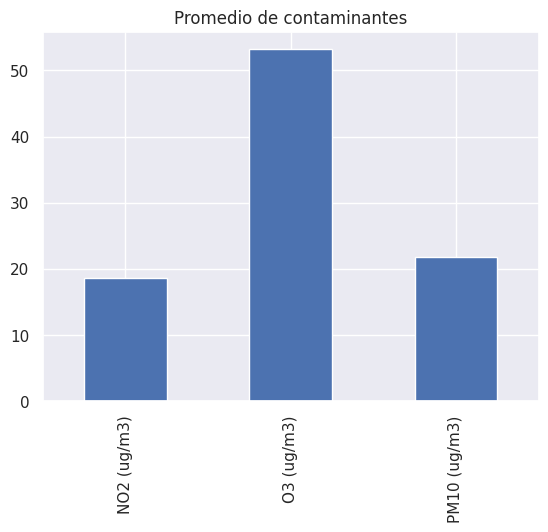

In [45]:
promedios = df[["NO2 (ug/m3)", "O3 (ug/m3)", "PM10 (ug/m3)"]].mean()

plt.figure()
promedios.plot(kind="bar")
plt.title("Promedio de contaminantes")
plt.show()

📌 Pregunta 3: ¿Qué provincia presenta mayor contaminación?

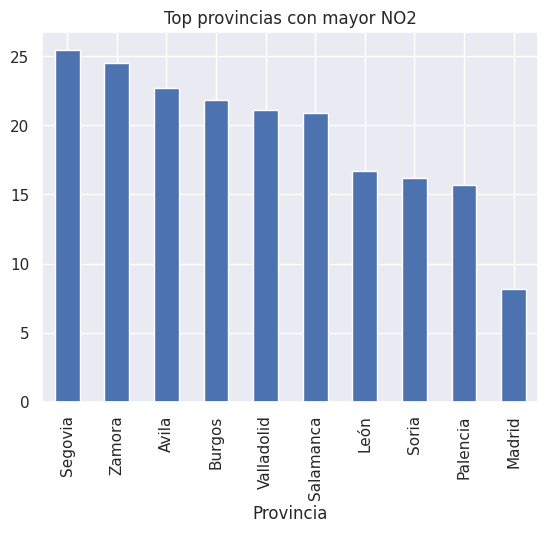

In [46]:
top_provincias = df.groupby("Provincia")["NO2 (ug/m3)"].mean().sort_values(ascending=False).head(10)

top_provincias.plot(kind="bar")
plt.title("Top provincias con mayor NO2")
plt.show()

Se identificó que ciertas provincias presentan mayores niveles promedio de contaminación, lo cual puede estar relacionado con actividad industrial o densidad poblacional.

📌 Pregunta 4: ¿Existen patrones estacionales en algunos contaminantes?

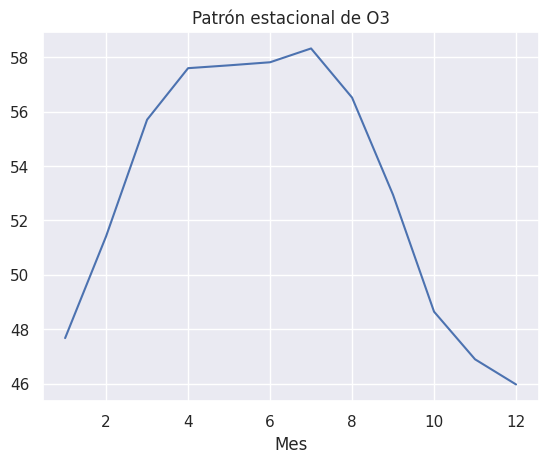

In [47]:
df.groupby("Mes")["O3 (ug/m3)"].mean().plot()
plt.title("Patrón estacional de O3")
plt.show()

#🧾 8. CONCLUSIONES
- El dataset presenta valores faltantes importantes.
- Existen outliers en varios contaminantes.
- Algunos contaminantes están correlacionados.
- Se observan variaciones en el tiempo.
- Diferencias entre provincias sugieren factores geográficos.